In [ ]:
from PIL import Image, ImageDraw

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  GEOMETRY MODEL — read this before changing anything.                    ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║  Page is WIDTH × HEIGHT pixels. A solid header rectangle of              ║
# ║  HEADER_HEIGHT rows fills the very top (rows 0 .. HEADER_HEIGHT−1).      ║
# ║  Everything below — rows HEADER_HEIGHT .. HEIGHT−1, full width — is the  ║
# ║  "usable rectangle" where dots live. Inside it, EVERY density places     ║
# ║  dots with the SAME MARGIN px gap between dot edge and rectangle edge    ║
# ║  on all four sides. Top, bottom, left, right are exactly equal.          ║
# ║                                                                          ║
# ║  ALL MATH IS EDGE-BASED — we never reason about dot "centers". PIL's     ║
# ║  paste() takes a top-left corner, so edge-math is the natural unit and   ║
# ║  avoids the DOT_SIZE//2 conversions that previously caused a 6 px        ║
# ║  top-margin bug (header was pinned 120 px from a dot CENTER while the    ║
# ║  other three margins were measured to the dot EDGE — mixing conventions  ║
# ║  cost DOT_SIZE//2 = 5 px, plus 1 px from inclusive-row arithmetic).      ║
# ║                                                                          ║
# ║  Lattice equations. For a chosen SPACING:                                ║
# ║    dot (i,j) top-left pixel =                                            ║
# ║        ( MARGIN + i·SPACING ,  HEADER_HEIGHT + MARGIN + j·SPACING )      ║
# ║    n_x = LATTICE_W // SPACING + 1                                        ║
# ║    n_y = LATTICE_H // SPACING + 1                                        ║
# ║  where                                                                   ║
# ║    LATTICE_W = WIDTH      − 2·MARGIN − DOT_SIZE                          ║
# ║    LATTICE_H = HEIGHT − HEADER_HEIGHT − 2·MARGIN − DOT_SIZE              ║
# ║                                                                          ║
# ║  For the right/bottom margin to land EXACTLY on MARGIN px (not less),    ║
# ║  SPACING must divide both LATTICE_W and LATTICE_H. With current values   ║
# ║  LATTICE_W = 8250 and LATTICE_H = 10500, gcd = 750. Allowed SPACINGs     ║
# ║  are divisors of 750: 1, 2, 3, 5, 6, 10, 15, 25, 30, 50, 75, 125, 150,   ║
# ║  250, 375, 750. (We use 250, 150, 125 in this notebook.)                 ║
# ║                                                                          ║
# ║  Even vs. odd DOT_SIZE: even sizes have a sub-pixel geometric center     ║
# ║  (no single "center pixel"); odd sizes have a true center pixel. Either  ║
# ║  works for our lattice — the offset is uniform — but parity matters for  ║
# ║  whether MARGIN comes out integer. With even WIDTH and even MARGIN,      ║
# ║  even DOT_SIZE is the safe choice.                                       ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# Page dimensions: 8.5" × 11" at 1000 DPI
WIDTH  = 8500
HEIGHT = 11000

BG_COLOR  = (255, 255, 255)   # white
DOT_COLOR = (210, 210, 210)   # very light gray

DOT_SIZE      = 10    # diameter of each dot in pixels
SUPERSAMPLE   = 8     # render each dot at 8× then downscale for AA
MARGIN        = 120   # empty pixels between dot edge and usable-rect edge (all 4 sides)
HEADER_HEIGHT = 250   # rows occupied by header rect at top of page

# Lattice extent (the box the dot top-left corners span, edge-to-edge):
LATTICE_W = WIDTH  - 2 * MARGIN - DOT_SIZE                   # 8250
LATTICE_H = HEIGHT - HEADER_HEIGHT - 2 * MARGIN - DOT_SIZE   # 10500

print(f"Canvas      : {WIDTH} × {HEIGHT} px")
print(f"Header rect : rows 0..{HEADER_HEIGHT-1}  ({HEADER_HEIGHT} rows tall)")
print(f"Usable rect : rows {HEADER_HEIGHT}..{HEIGHT-1}  ({HEIGHT-HEADER_HEIGHT} rows tall)")
print(f"Lattice     : {LATTICE_W} × {LATTICE_H} px (SPACING must divide both)")
print(f"Margin      : {MARGIN} px on all 4 sides of usable rect (dot-edge to rect-edge)")

In [27]:
# Build a single antialiased circular dot template.
# Draw at SUPERSAMPLE× size, then downscale with LANCZOS for smooth edges.
ss = DOT_SIZE * SUPERSAMPLE
dot_hi = Image.new('RGB', (ss, ss), BG_COLOR)
ImageDraw.Draw(dot_hi).ellipse([0, 0, ss - 1, ss - 1], fill=DOT_COLOR)
dot_template = dot_hi.resize((DOT_SIZE, DOT_SIZE), Image.LANCZOS)

print(f"Dot template: {DOT_SIZE}×{DOT_SIZE} px (rendered at {ss}×{ss} then downscaled)")

Dot template: 10×10 px (rendered at 80×80 then downscaled)


In [ ]:
# Stamp the dotted grid: SPACING=250 px between dots.
SPACING = 250
assert LATTICE_W % SPACING == 0 and LATTICE_H % SPACING == 0, \
    f"SPACING={SPACING} must divide LATTICE_W={LATTICE_W} and LATTICE_H={LATTICE_H}"

n_x = LATTICE_W // SPACING + 1
n_y = LATTICE_H // SPACING + 1

img = Image.new('RGB', (WIDTH, HEIGHT), BG_COLOR)
for i in range(n_x):
    x = MARGIN + i * SPACING
    for j in range(n_y):
        y = HEADER_HEIGHT + MARGIN + j * SPACING
        img.paste(dot_template, (x, y))

print(f"Dotted grid : {n_x} × {n_y} = {n_x * n_y} dots (spacing {SPACING}px)")

In [ ]:
# Header: solid rectangle at the very top, rows 0 .. HEADER_HEIGHT−1.
# This is what defines the usable rectangle below it.
ImageDraw.Draw(img).rectangle([0, 0, WIDTH - 1, HEADER_HEIGHT - 1], fill=DOT_COLOR)
print(f"Header rect : (0,0) → ({WIDTH-1},{HEADER_HEIGHT-1})  [{WIDTH}×{HEADER_HEIGHT}px]")

Saved → dotted-paper.png


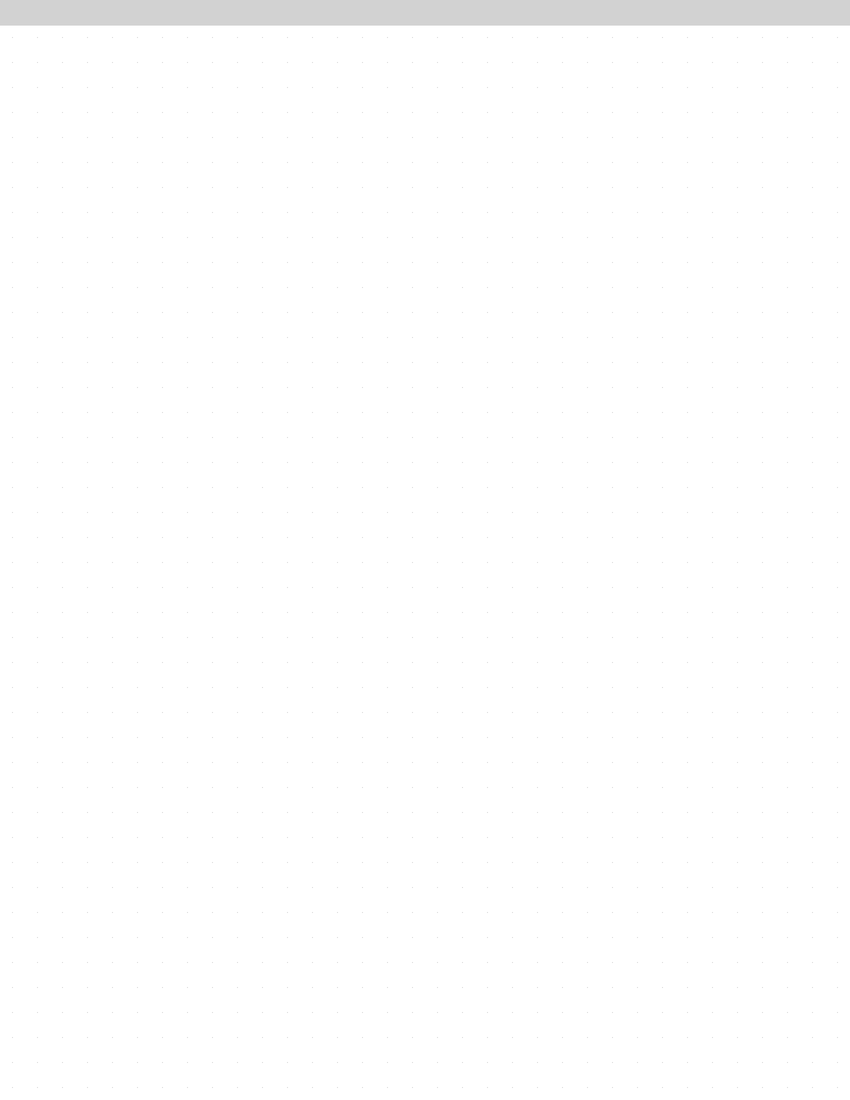

In [30]:
# Save and preview
output_path = "dotted-paper.png"
img.save(output_path, "PNG")
print(f"Saved → {output_path}")

from IPython.display import display
display(img.resize((850, 1100), Image.LANCZOS))

In [ ]:
# Super-dotted: SPACING=125, exactly half of dotted. This is a pure 2×
# subdivision — every dotted-grid dot is preserved AND a new dot is inserted
# at every midpoint on both axes (4× total density). The lattice nests
# perfectly inside the dotted lattice. Same usable rectangle, same 120 px
# margins on all 4 sides.
SPACING_SUPER = 125
assert LATTICE_W % SPACING_SUPER == 0 and LATTICE_H % SPACING_SUPER == 0

n_x_s = LATTICE_W // SPACING_SUPER + 1
n_y_s = LATTICE_H // SPACING_SUPER + 1

img_super = Image.new('RGB', (WIDTH, HEIGHT), BG_COLOR)
for i in range(n_x_s):
    x = MARGIN + i * SPACING_SUPER
    for j in range(n_y_s):
        y = HEADER_HEIGHT + MARGIN + j * SPACING_SUPER
        img_super.paste(dot_template, (x, y))

ImageDraw.Draw(img_super).rectangle([0, 0, WIDTH - 1, HEADER_HEIGHT - 1], fill=DOT_COLOR)

output_path_super = "super-dotted-paper.png"
img_super.save(output_path_super, "PNG")
print(f"Super-dotted: {n_x_s} × {n_y_s} = {n_x_s * n_y_s} dots (spacing {SPACING_SUPER}px)")
print(f"Saved → {output_path_super}")

from IPython.display import display
display(img_super.resize((850, 1100), Image.LANCZOS))

In [ ]:
# Extra-dotted: SPACING=150 — the UNIQUE integer spacing strictly between
# dotted (250) and super-dotted (125) that preserves all four 120 px margins
# exactly. Derivation: SPACING must divide both LATTICE_W=8250 and
# LATTICE_H=10500 so the last dot lands exactly on the right/bottom margin.
# gcd(8250, 10500) = 750. Divisors of 750 in the open interval (125, 250)
# are exactly {150}. Density vs. dotted is (250/150)² ≈ 2.78×. Does NOT
# nest into the dotted or super lattice (lcm with either is 750), but the
# usable rectangle, header, and margins are pixel-identical.
SPACING_EXTRA = 150
assert LATTICE_W % SPACING_EXTRA == 0 and LATTICE_H % SPACING_EXTRA == 0

n_x_e = LATTICE_W // SPACING_EXTRA + 1
n_y_e = LATTICE_H // SPACING_EXTRA + 1

img_extra = Image.new('RGB', (WIDTH, HEIGHT), BG_COLOR)
for i in range(n_x_e):
    x = MARGIN + i * SPACING_EXTRA
    for j in range(n_y_e):
        y = HEADER_HEIGHT + MARGIN + j * SPACING_EXTRA
        img_extra.paste(dot_template, (x, y))

ImageDraw.Draw(img_extra).rectangle([0, 0, WIDTH - 1, HEADER_HEIGHT - 1], fill=DOT_COLOR)

output_path_extra = "extra-dotted-paper.png"
img_extra.save(output_path_extra, "PNG")
print(f"Extra-dotted: {n_x_e} × {n_y_e} = {n_x_e * n_y_e} dots (spacing {SPACING_EXTRA}px)")
print(f"Saved → {output_path_extra}")

from IPython.display import display
display(img_extra.resize((850, 1100), Image.LANCZOS))